In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
states = [0, 1, 2]
actions = [0, 1]

# Transition Probabilities
P = {
    0: {0: [0.7, 0.3, 0.0], 1: [0.4, 0.6, 0.0]},
    1: {0: [0.1, 0.6, 0.3], 1: [0.0, 0.3, 0.7]},
    2: {0: [0.0, 0.0, 1.0], 1: [0.0, 0.0, 1.0]}
}

# Rewards
R = {
    0: {0: 5, 1: 10},
    1: {0: -1, 1: 2},
    2: {0: 0, 1: 0}
}

gamma = 0.9

In [3]:
def value_iteration(P, R, gamma, iterations=10):
    V = np.zeros(len(states))
    history = []

    for i in range(iterations):
        new_V = np.zeros(len(states))
        
        for s in states:
            action_values = []
            
            for a in actions:
                value = 0
                for s_next in states:
                    value += P[s][a][s_next] * (R[s][a] + gamma * V[s_next])
                action_values.append(value)
            
            new_V[s] = max(action_values)
        
        V = new_V
        history.append(V.copy())
        print(f"Iteration {i+1}: {V}")
    
    return V, history

In [4]:
optimal_values, history = value_iteration(P, R, gamma)

print("\nOptimal Values:", optimal_values)

Iteration 1: [10.  2.  0.]
Iteration 2: [14.68  2.54  0.  ]
Iteration 3: [16.6564  2.6858  0.    ]
Iteration 4: [17.446636  2.725166  0.      ]
Iteration 5: [17.7523786   2.73579482  0.        ]
Iteration 6: [17.8681855  2.7386646  0.       ]
Iteration 7: [17.91142566  2.73943944  0.        ]
Iteration 8: [17.92741054  2.73964865  0.        ]
Iteration 9: [17.93327806  2.73970514  0.        ]
Iteration 10: [17.93542088  2.73972039  0.        ]

Optimal Values: [17.93542088  2.73972039  0.        ]


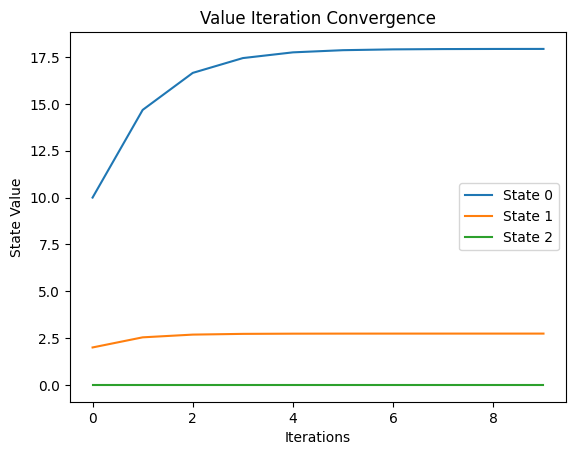

In [5]:
history = np.array(history)

plt.figure()
for i in range(len(states)):
    plt.plot(history[:, i], label=f"State {i}")

plt.title("Value Iteration Convergence")
plt.xlabel("Iterations")
plt.ylabel("State Value")
plt.legend()
plt.show()

In [6]:
def extract_policy(P, R, V, gamma):
    policy = {}

    for s in states:
        action_values = []
        
        for a in actions:
            value = 0
            for s_next in states:
                value += P[s][a][s_next] * (R[s][a] + gamma * V[s_next])
            action_values.append(value)
        
        policy[s] = np.argmax(action_values)
    
    return policy

policy = extract_policy(P, R, optimal_values, gamma)

print("Optimal Policy:", policy)

Optimal Policy: {0: 1, 1: 1, 2: 0}


In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
data = load_iris()

X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [11]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



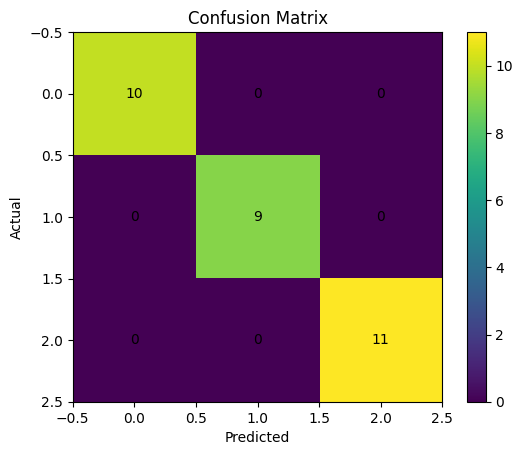

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

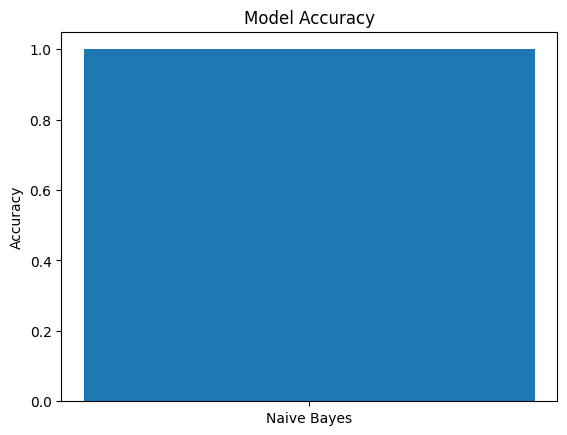

In [13]:
accuracy = accuracy_score(y_test, y_pred)

plt.figure()
plt.bar(["Naive Bayes"], [accuracy])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.show()